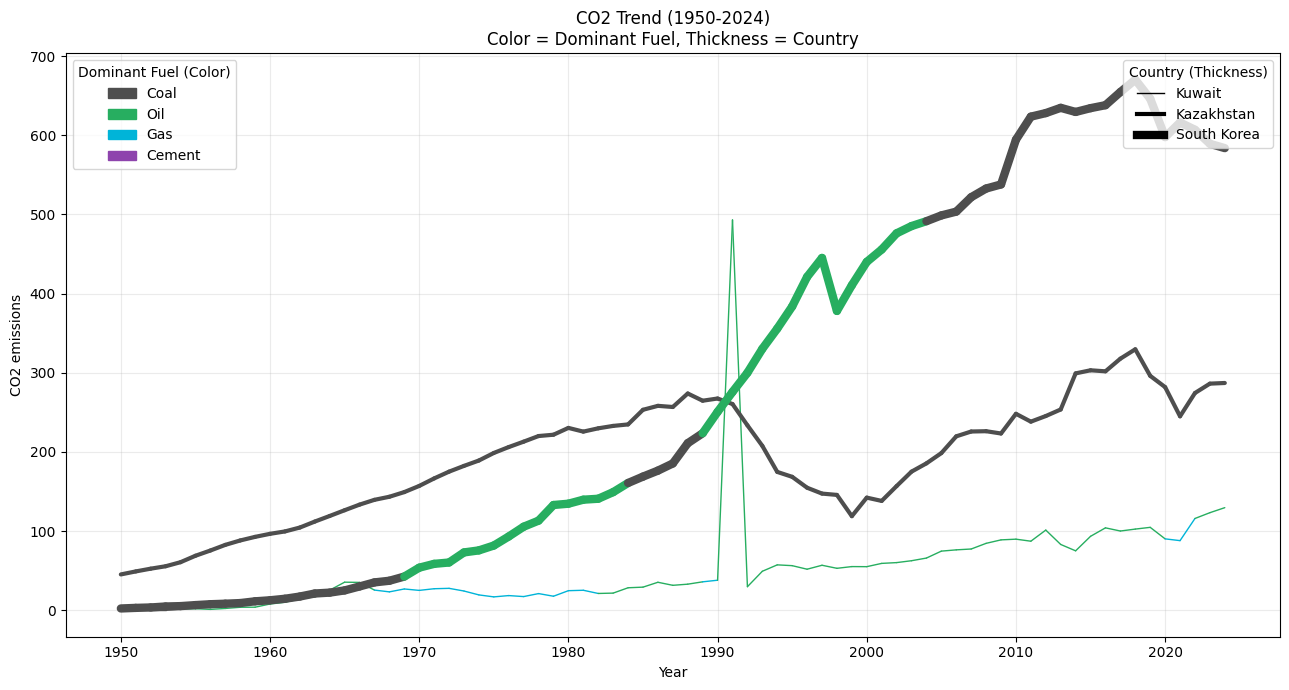

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
df = pd.read_csv("owid-co2-data.csv")
# 1) Countries
countries = ["Kuwait", "Kazakhstan", "South Korea"]

# 2) Clean
tmp = df.copy()
tmp = tmp[tmp["iso_code"].astype(str).str.len() == 3].copy()
tmp = tmp[tmp["country"] != "World"].copy()

fuel_cols = ["coal_co2", "oil_co2", "gas_co2", "cement_co2"]
need_cols = ["country", "year", "co2"] + fuel_cols
tmp = tmp.dropna(subset=["country", "year", "co2"]).copy()
tmp["year"] = pd.to_numeric(tmp["year"], errors="coerce")
tmp = tmp.dropna(subset=["year"])
tmp["year"] = tmp["year"].astype(int)
tmp[fuel_cols] = tmp[fuel_cols].fillna(0)

latest_year = int(tmp["year"].max())
start_year = latest_year - 74
tmp75 = tmp[tmp["year"] >= start_year].copy()

plot_df = tmp75[tmp75["country"].isin(countries)].copy()
plot_df["dominant_fuel"] = plot_df[fuel_cols].idxmax(axis=1)

# 3) Style maps
fuel_colors = {
    "coal_co2": "#4e4e4e",
    "oil_co2": "#27ae60",
    "gas_co2": "#00b4d8",
    "cement_co2": "#8e44ad",
}
fuel_labels = {
    "coal_co2": "Coal",
    "oil_co2": "Oil",
    "gas_co2": "Gas",
    "cement_co2": "Cement",
}
country_width = {
    "Kuwait": 1.0,
    "Kazakhstan": 3.0,
    "South Korea": 6.0,
}

# 4) Plot
plt.figure(figsize=(13, 7))
ax = plt.gca()

for c in countries:
    d = plot_df[plot_df["country"] == c].sort_values("year")
    years = d["year"].values
    co2 = d["co2"].values
    dom = d["dominant_fuel"].values
    lw = country_width[c]

    # segment-by-segment so color can change by fuel type
    for i in range(len(d) - 1):
        ax.plot(
            years[i:i+2],
            co2[i:i+2],
            color=fuel_colors.get(dom[i], "#999999"),
            linewidth=lw,
            solid_capstyle="round"
        )

plt.title(f"CO2 Trend ({start_year}-{latest_year})\nColor = Dominant Fuel, Thickness = Country")
plt.xlabel("Year")
plt.ylabel("CO2 emissions")
plt.grid(alpha=0.25)

# 5) Legends
fuel_handles = [mpatches.Patch(color=fuel_colors[k], label=fuel_labels[k]) for k in fuel_cols]
country_handles = [Line2D([0], [0], color="black", lw=country_width[c], label=c) for c in countries]

leg1 = ax.legend(handles=fuel_handles, title="Dominant Fuel (Color)", loc="upper left")
ax.add_artist(leg1)
ax.legend(handles=country_handles, title="Country (Thickness)", loc="upper right")

plt.tight_layout()
plt.show()


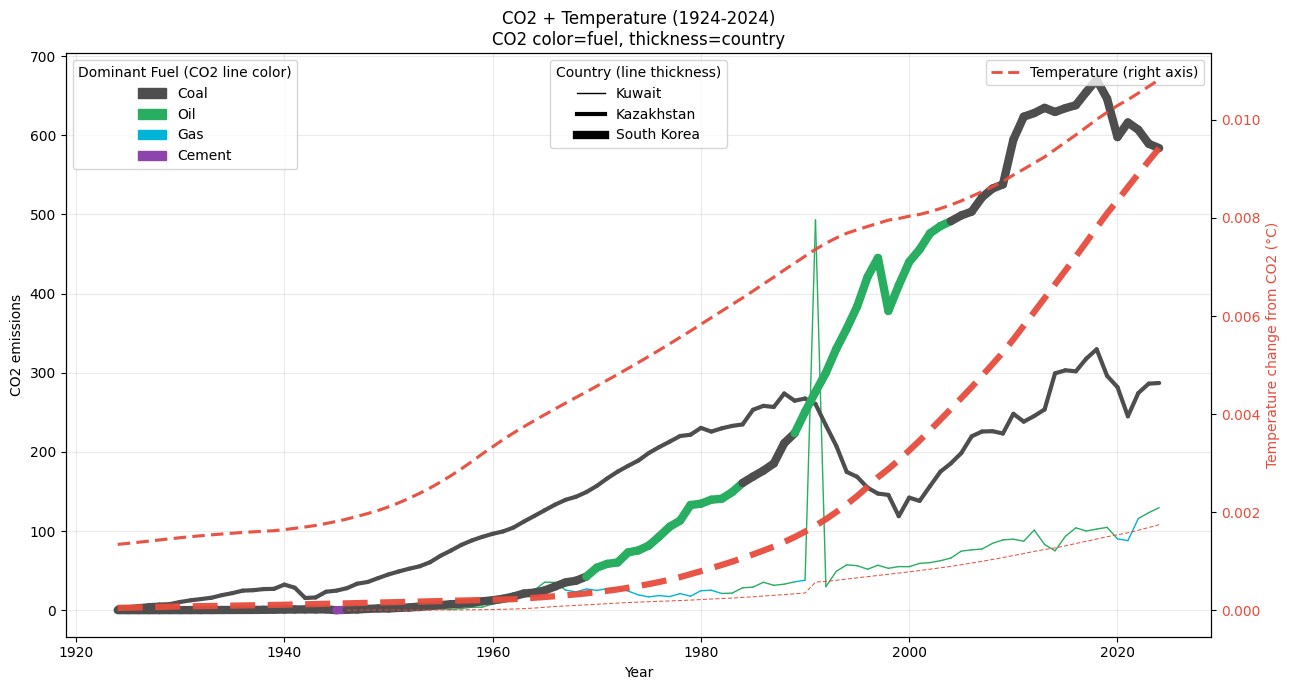

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

# 1) Countries
countries = ["Kuwait", "Kazakhstan", "South Korea"]

# 2) Clean
tmp = df.copy()
tmp = tmp[tmp["iso_code"].astype(str).str.len() == 3].copy()
tmp = tmp[tmp["country"] != "World"].copy()

fuel_cols = ["coal_co2", "oil_co2", "gas_co2", "cement_co2"]
tmp = tmp.dropna(subset=["country", "year", "co2", "temperature_change_from_co2"]).copy()
tmp["year"] = pd.to_numeric(tmp["year"], errors="coerce")
tmp = tmp.dropna(subset=["year"])
tmp["year"] = tmp["year"].astype(int)
tmp[fuel_cols] = tmp[fuel_cols].fillna(0)

latest_year = int(tmp["year"].max())
start_year = latest_year - 100
tmp75 = tmp[tmp["year"] >= start_year].copy()

plot_df = tmp75[tmp75["country"].isin(countries)].copy()
plot_df["dominant_fuel"] = plot_df[fuel_cols].idxmax(axis=1)

# 3) Style maps
fuel_colors = {
    "coal_co2": "#4e4e4e",
    "oil_co2": "#27ae60",
    "gas_co2": "#00b4d8",
    "cement_co2": "#8e44ad",
}
fuel_labels = {
    "coal_co2": "Coal",
    "oil_co2": "Oil",
    "gas_co2": "Gas",
    "cement_co2": "Cement",
}
country_width = {
    "Kuwait": 1.0,
    "Kazakhstan": 3.0,
    "South Korea": 6.0,
}
TEMP_COLOR = "#e74c3c"

# 4) Plot (dual axis)
fig, ax1 = plt.subplots(figsize=(13, 7))
ax2 = ax1.twinx()

for c in countries:
    d = plot_df[plot_df["country"] == c].sort_values("year")
    years = d["year"].values
    co2 = d["co2"].values
    temp = d["temperature_change_from_co2"].values
    dom = d["dominant_fuel"].values
    lw = country_width[c]

    # CO2 line segments: color by dominant fuel
    for i in range(len(d) - 1):
        ax1.plot(
            years[i:i+2], co2[i:i+2],
            color=fuel_colors.get(dom[i], "#999999"),
            linewidth=lw,
            solid_capstyle="round"
        )

    # Temperature line: same thickness by country, dashed red
    ax2.plot(
        years, temp,
        color=TEMP_COLOR,
        linestyle=(0, (4, 2)),
        linewidth=lw * 0.75,
        alpha=0.95
    )

ax1.set_title(f"CO2 + Temperature ({start_year}-{latest_year})\nCO2 color=fuel, thickness=country")
ax1.set_xlabel("Year")
ax1.set_ylabel("CO2 emissions")
ax2.set_ylabel("Temperature change from CO2 (°C)", color=TEMP_COLOR)
ax2.tick_params(axis="y", labelcolor=TEMP_COLOR)
ax1.grid(alpha=0.25)

# 5) Legends
fuel_handles = [mpatches.Patch(color=fuel_colors[k], label=fuel_labels[k]) for k in fuel_cols]
country_handles = [Line2D([0], [0], color="black", lw=country_width[c], label=c) for c in countries]
temp_handle = [Line2D([0], [0], color=TEMP_COLOR, lw=2, linestyle=(0, (4, 2)), label="Temperature (right axis)")]

leg1 = ax1.legend(handles=fuel_handles, title="Dominant Fuel (CO2 line color)", loc="upper left")
ax1.add_artist(leg1)

leg2 = ax1.legend(handles=country_handles, title="Country (line thickness)", loc="upper center")
ax1.add_artist(leg2)

ax1.legend(handles=temp_handle, loc="upper right")

plt.tight_layout()
plt.show()


/var/folders/xy/_xs5thqj5x5b3g2td0sj40wm0000gn/T/ipykernel_21125/2788061328.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/xy/_xs5thqj5x5b3g2td0sj40wm0000gn/T/ipykernel_21125/2788061328.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


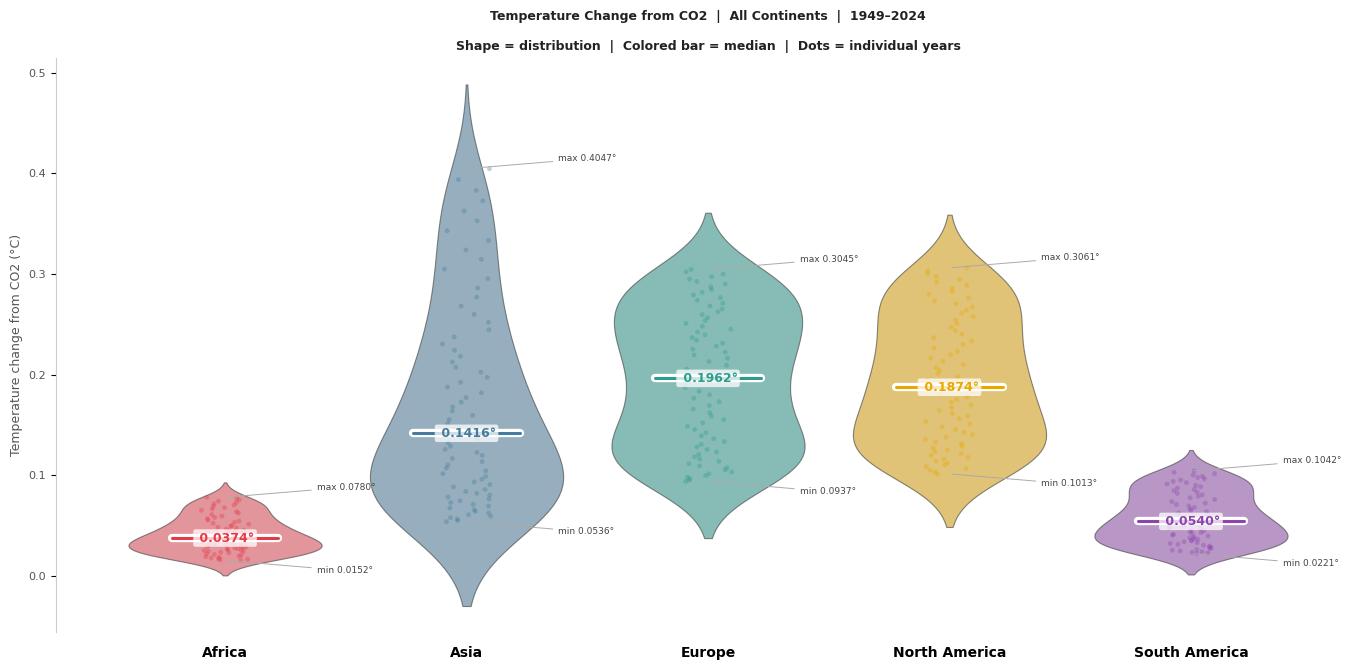

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("owid-co2-data.csv")

tmp = (df.dropna(subset=["country", "year", "temperature_change_from_co2"])
         .assign(year=lambda x: pd.to_numeric(x["year"], errors="coerce"))
         .dropna(subset=["year"])
         .assign(year=lambda x: x["year"].astype(int)))

latest_year = tmp["year"].max()
start_year  = latest_year - 75
continents  = ["Africa", "Asia", "Europe", "North America", "South America"]
palette     = ["#e63946", "#457b9d", "#2a9d8f", "#e9a800", "#8e44ad"]

continent_df = tmp[tmp["country"].isin(continents) & (tmp["year"] >= start_year)]

fig, ax = plt.subplots(figsize=(14, 7))

sns.violinplot(
    data=continent_df,
    x="country", y="temperature_change_from_co2",
    order=continents, palette=palette,
    inner=None, linewidth=0.8, alpha=0.6, ax=ax
)

sns.stripplot(
    data=continent_df,
    x="country", y="temperature_change_from_co2",
    order=continents, palette=palette,
    size=3.5, alpha=0.35, jitter=True, ax=ax
)

for xi, (cont, col) in enumerate(zip(continents, palette)):
    d = continent_df[continent_df["country"] == cont]["temperature_change_from_co2"].dropna()
    if d.empty:
        continue

    med = np.median(d)
    mn  = d.min()
    mx  = d.max()

    # White glow behind median bar so text is readable
    ax.plot([xi - 0.22, xi + 0.22], [med, med],
            color="white", linewidth=6, solid_capstyle="round", zorder=5)
    # Colored median bar
    ax.plot([xi - 0.22, xi + 0.22], [med, med],
            color=col, linewidth=2.2, solid_capstyle="round", zorder=6)

    # ── Text sitting ON the median line ──────────────────────────
    ax.text(xi, med, f" {med:.4f}°",
            fontsize=9, color=col, fontweight="bold",
            va="center", ha="center",
            zorder=7,
            bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.75))

    # Max label — right side with leader line
    ax.annotate(f"max {mx:.4f}°",
                xy=(xi, mx),
                xytext=(xi + 0.38, mx + 0.010),
                fontsize=6.5, color="#444444", ha="left", va="center",
                arrowprops=dict(arrowstyle="-", color="#aaaaaa", lw=0.7),
                annotation_clip=False)

    # Min label — right side with leader line
    ax.annotate(f"min {mn:.4f}°",
                xy=(xi, mn),
                xytext=(xi + 0.38, mn - 0.010),
                fontsize=6.5, color="#444444", ha="left", va="center",
                arrowprops=dict(arrowstyle="-", color="#aaaaaa", lw=0.7),
                annotation_clip=False)

# Styling
ax.set_xlabel("")
ax.set_ylabel("Temperature change from CO2 (°C)", fontsize=9, color="#555555")
ax.set_title(
    f"Temperature Change from CO2  |  All Continents  |  {start_year}–{latest_year}\n\n"
    "Shape = distribution  |  Colored bar = median  |  Dots = individual years",
    fontsize=9, color="#222222", loc="center", fontweight="bold"
)
ax.set_xticks(range(len(continents)))
ax.set_xticklabels(continents, fontsize=10, fontweight="bold", ha="center")
ax.set_xlim(-0.7, len(continents) - 0.3)

for spine in ["top", "right", "bottom"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.tick_params(axis="y", labelsize=8, labelcolor="#555555")
ax.tick_params(axis="x", length=0, pad=10)

plt.tight_layout(pad=1.8)
plt.show()

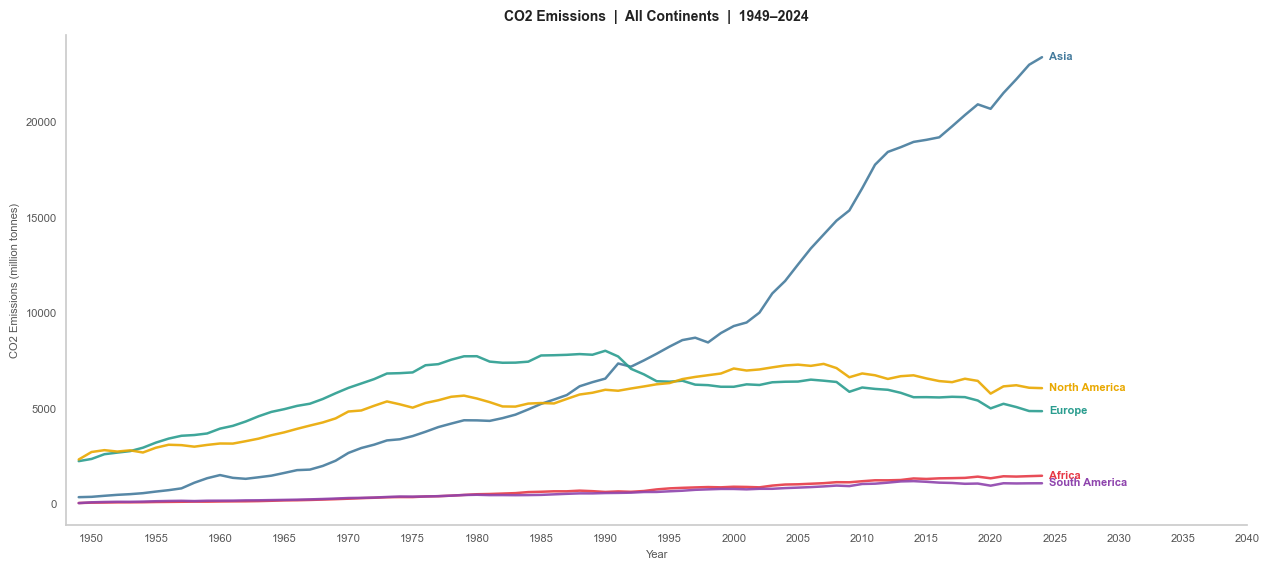

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns

df = pd.read_csv("owid-co2-data.csv")

# Data prep
tmp = (df.dropna(subset=["country", "year", "co2"])
         .assign(year=lambda x: pd.to_numeric(x["year"], errors="coerce"))
         .dropna(subset=["year"])
         .assign(year=lambda x: x["year"].astype(int)))

latest_year = int(tmp["year"].max())
start_year  = latest_year - 75

continents = ["Africa", "Asia", "Europe", "North America", "South America"]
palette    = ["#e63946", "#457b9d", "#2a9d8f", "#e9a800", "#8e44ad"]

continent_df = (tmp[tmp["country"].isin(continents) & (tmp["year"] >= start_year)]
                .sort_values("year"))

# Plot
sns.set_theme(style="white", font="sans-serif")
fig, ax = plt.subplots(figsize=(13, 6))

sns.lineplot(
    data=continent_df,
    x="year", y="co2",
    hue="country",
    hue_order=continents,
    palette=palette,
    linewidth=1.8,
    alpha=0.9,
    legend=False,
    ax=ax
)

# End-of-line labels
for cont, col in zip(continents, palette):
    d = continent_df[continent_df["country"] == cont]
    if d.empty:
        continue
    last = d.iloc[-1]
    ax.annotate(cont, xy=(last["year"], last["co2"]),
                xytext=(5, 0), textcoords="offset points",
                fontsize=8, color=col, va="center", fontweight="bold")

# Styling
sns.despine(ax=ax, top=True, right=True)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")
ax.tick_params(length=3, width=0.5, direction="out", color="#cccccc",
               labelsize=8, labelcolor="#555555")
ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=20))
ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
ax.set_xlim(start_year - 1, latest_year + 16)
ax.set_xlabel("Year", fontsize=8, color="#555555")
ax.set_ylabel("CO2 Emissions (million tonnes)", fontsize=8, color="#555555")
ax.set_title(f"CO2 Emissions  |  All Continents  |  {start_year}–{latest_year}",
             fontsize=10, color="#222222", loc="center",fontweight="bold", pad=10)

plt.tight_layout(pad=1.5)
plt.show()

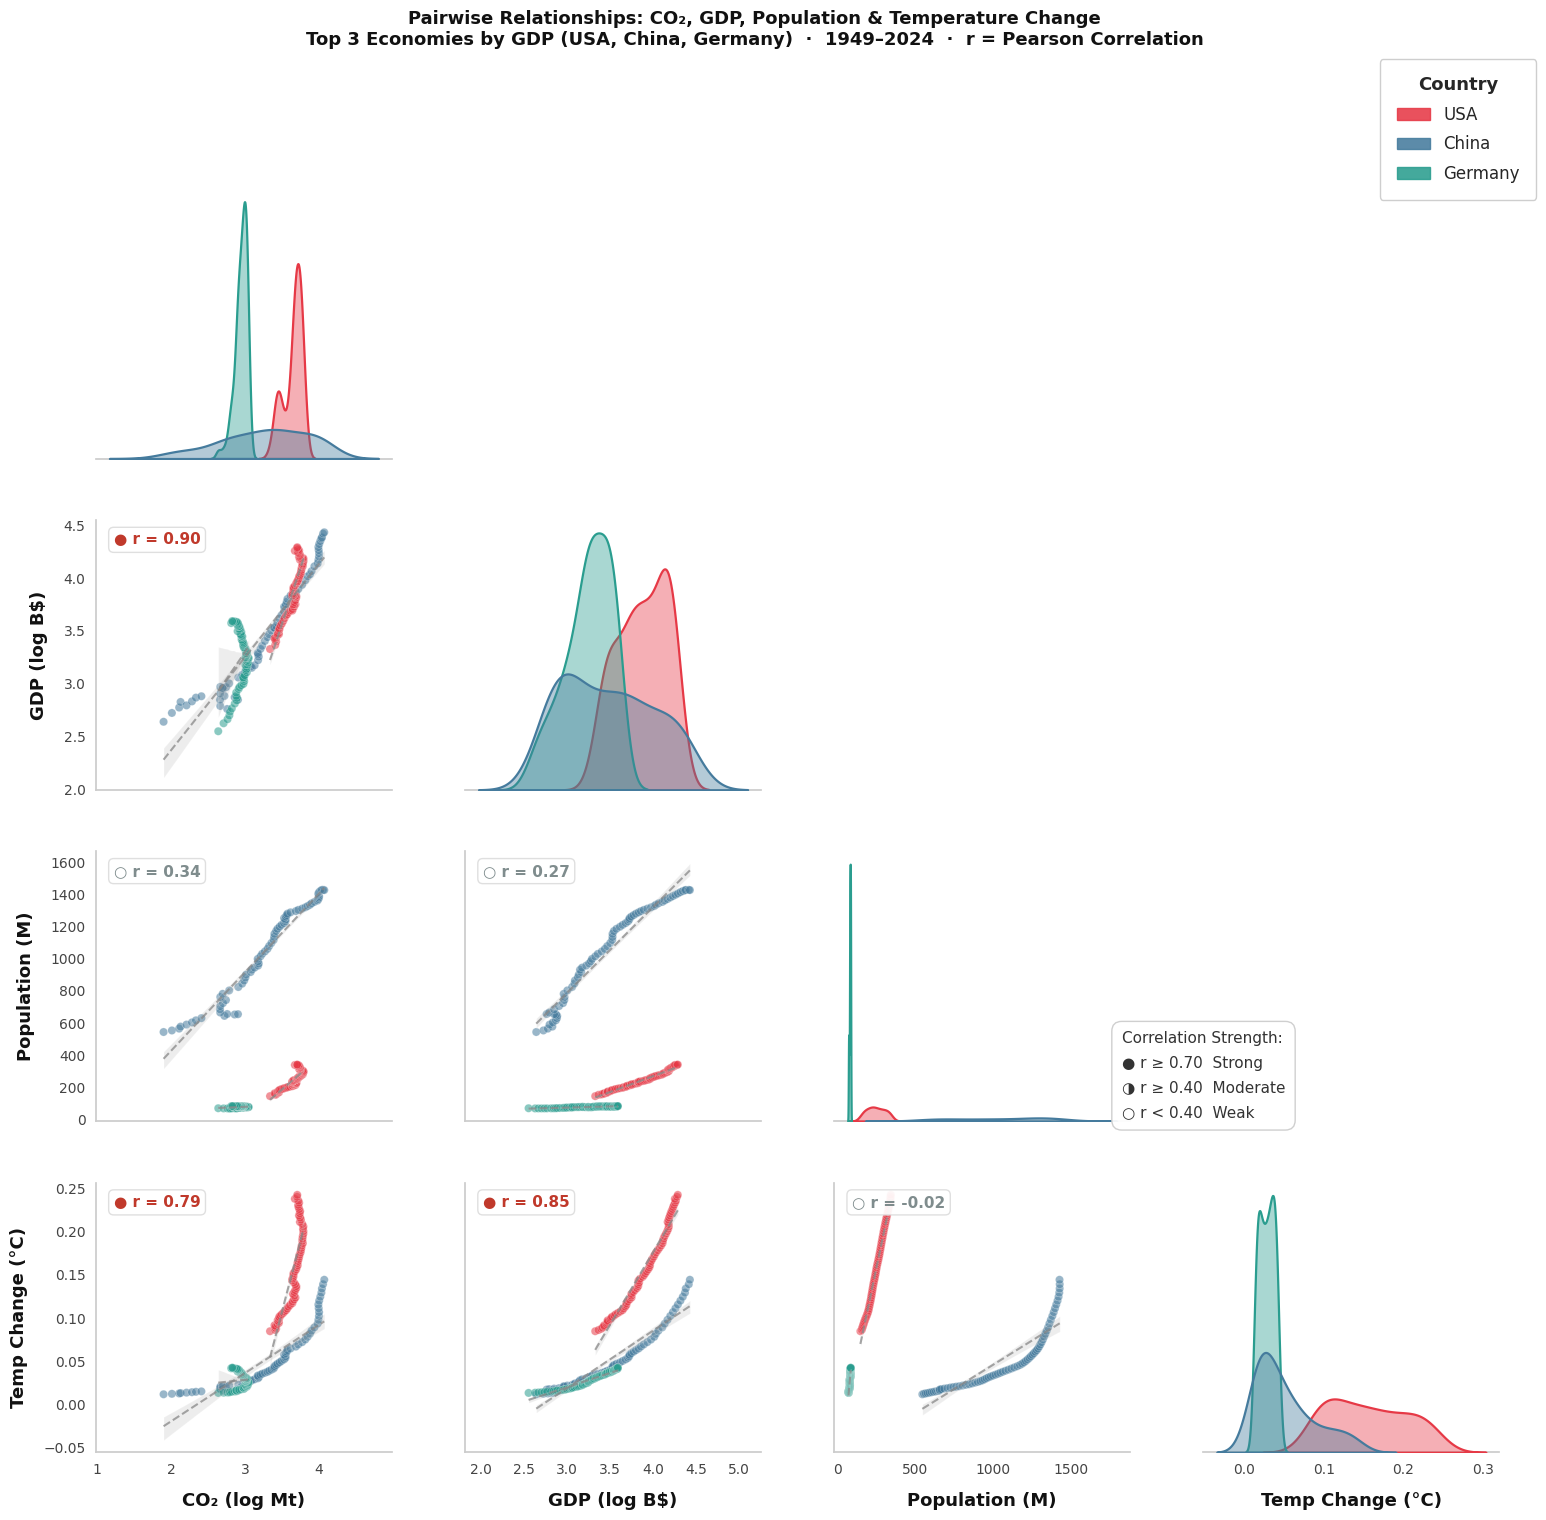

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

# ── Load real data ────────────────────────────────────────────────
df = pd.read_csv("usa_china_germany.csv")

latest_year = int(df["year"].max())
start_year  = latest_year - 75

df = df[df["year"] >= start_year].copy()
df["country"] = df["country"].replace({"United States": "USA"})

plot_df = df[["country", "year", "co2", "gdp", "population",
              "temperature_change_from_co2"]].dropna().copy()

# ── Transform ─────────────────────────────────────────────────────
plot_df["CO₂ (log Mt)"]    = np.log10(plot_df["co2"].clip(lower=1))
plot_df["GDP (log B$)"]     = np.log10((plot_df["gdp"] / 1e9).clip(lower=1))
plot_df["Population (M)"]   = plot_df["population"] / 1e6
plot_df["Temp Change (°C)"] = plot_df["temperature_change_from_co2"]

vars_list = ["CO₂ (log Mt)", "GDP (log B$)", "Population (M)", "Temp Change (°C)"]

country_palette = {
    "USA":     "#e63946",
    "China":   "#457b9d",
    "Germany": "#2a9d8f",
}

# ── PairGrid ──────────────────────────────────────────────────────
sns.set_theme(style="white", font="DejaVu Sans")

g = sns.PairGrid(
    plot_df,
    vars=vars_list,
    hue="country",
    palette=country_palette,
    corner=True,
    diag_sharey=False,
    height=3.8,
    aspect=1.05,
)

g.map_diag(sns.kdeplot, fill=True, alpha=0.4, linewidth=1.6)

g.map_lower(sns.scatterplot,
            s=35, alpha=0.55, linewidths=0.25, edgecolor="white")

g.map_lower(sns.regplot,
            scatter=False, ci=95,
            line_kws={"color": "#888888", "linewidth": 1.5,
                      "linestyle": "--", "alpha": 0.75})

# ── Pearson r annotations ─────────────────────────────────────────
for i, var_y in enumerate(vars_list):
    for j, var_x in enumerate(vars_list):
        if j >= i:
            continue
        ax = g.axes[i, j]
        if ax is None:
            continue
        r = plot_df[[var_x, var_y]].dropna().corr().iloc[0, 1]
        if abs(r) >= 0.7:
            r_col, r_icon = "#c0392b", "●"
        elif abs(r) >= 0.4:
            r_col, r_icon = "#e67e22", "◑"
        else:
            r_col, r_icon = "#7f8c8d", "○"
        ax.annotate(f"{r_icon} r = {r:.2f}",
                    xy=(0.06, 0.91), xycoords="axes fraction",
                    fontsize=11, color=r_col, fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.33",
                              fc="white", ec="#dddddd", alpha=0.93))

# ── Axis styling ──────────────────────────────────────────────────
n_vars = len(vars_list)
for i in range(n_vars):
    for j in range(n_vars):
        ax = g.axes[i, j]
        if ax is None:
            continue
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        ax.spines["left"].set_color("#cccccc")
        ax.spines["bottom"].set_color("#cccccc")
        ax.tick_params(labelsize=10, labelcolor="#444444", length=4)

for j, var_x in enumerate(vars_list):
    ax = g.axes[n_vars - 1, j]
    if ax is not None:
        ax.set_xlabel(var_x, fontsize=13, fontweight="bold",
                      color="#111111", labelpad=11)

for i, var_y in enumerate(vars_list):
    ax = g.axes[i, 0]
    if ax is not None:
        ax.set_ylabel(var_y, fontsize=13, fontweight="bold",
                      color="#111111", labelpad=11)

# ── Legend ────────────────────────────────────────────────────────
if g.legend:
    g.legend.remove()

handles = [mpatches.Patch(color=col, label=country, alpha=0.88)
           for country, col in country_palette.items()]

leg = g.figure.legend(
    handles=handles,
    title="Country",
    fontsize=12, title_fontsize=13,
    framealpha=0.96, edgecolor="#cccccc",
    loc="upper right",
    bbox_to_anchor=(0.995, 0.995),
    borderpad=1.0, labelspacing=0.7,
)
leg.get_title().set_fontweight("bold")

# ── Correlation key ───────────────────────────────────────────────
g.figure.text(0.73, 0.35,
              "Correlation Strength:\n"
              "● r ≥ 0.70  Strong\n"
              "◑ r ≥ 0.40  Moderate\n"
              "○ r < 0.40  Weak",
              fontsize=11, color="#333333", va="top", ha="left",
              linespacing=1.8,
              bbox=dict(boxstyle="round,pad=0.65", fc="white",
                        ec="#cccccc", alpha=0.94))

# ── Title ─────────────────────────────────────────────────────────
g.figure.suptitle(
    f"Pairwise Relationships: CO₂, GDP, Population & Temperature Change\n"
    f"Top 3 Economies by GDP (USA, China, Germany)  ·  {start_year}–{latest_year}"
    "  ·  r = Pearson Correlation",
    fontsize=13, fontweight="bold", color="#111111", y=1.022,
)

plt.tight_layout(pad=3.2)
plt.savefig("pairwise_countries_real.png", dpi=160, bbox_inches="tight", facecolor="white")
plt.show()